# Zadanie 09 - `Badania przypadków klinicznych: analiza danych pacjentów i budowa modeli predykcyjnych w oparciu o rzeczywiste przypadki`

**Wariant 2:** Random Forest + strojenie progu dla minimalizacji FN

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, precision_recall_curve
)

np.random.seed(42)
pd.set_option("display.max_columns", 100)


## 1. Wczytanie danych

In [2]:
DATA_PATH = "cases_clinical_for_lab12.csv"

df = pd.read_csv(DATA_PATH)
print("Kształt danych:", df.shape)
print("\nPierwsze 5 wierszy:")
print(df.head())


Kształt danych: (1000, 9)

Pierwsze 5 wierszy:
  sex  age   bmi  systolic_bp  diastolic_bp  glucose smoker family_history  \
0   M   81  31.7        109.0            84    110.0     no             no   
1   F   22  21.5        105.0            65     98.0     no            yes   
2   M   46  21.6        126.0            66    123.0     no            yes   
3   M   50  28.3        110.0            66     87.0     no             no   
4   F   75  31.7        119.0            89    123.0    yes             no   

   high_risk_cvd  
0              1  
1              0  
2              1  
3              0  
4              1  


## 2. Opis problemu i danych

In [5]:
print("\n--- Opis danych ---")
print("Kolumny:", list(df.columns))

print("Brakujące wartości (%):")
print(df.isna().mean() * 100)

print("\nTypy zmiennych (DataFrame Info):")
print(df.info())



--- Opis danych ---
Kolumny: ['sex', 'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose', 'smoker', 'family_history', 'high_risk_cvd']
Brakujące wartości (%):
sex               0.0
age               0.0
bmi               6.0
systolic_bp       3.4
diastolic_bp      0.0
glucose           5.6
smoker            0.0
family_history    0.0
high_risk_cvd     0.0
dtype: float64

Typy zmiennych (DataFrame Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             1000 non-null   object 
 1   age             1000 non-null   int64  
 2   bmi             940 non-null    float64
 3   systolic_bp     966 non-null    float64
 4   diastolic_bp    1000 non-null   int64  
 5   glucose         944 non-null    float64
 6   smoker          1000 non-null   object 
 7   family_history  1000 non-null   object 
 8   high_risk_cvd   1000 non-null 

### Rozkład zmiennej docelowej

In [12]:
target_col = "high_risk_cvd"
print(f"\nRozkład zmiennej docelowej '{target_col}':\n")

# Zmienna docelowa: wysokie ryzyko chorób sercowo-naczyniowych (1 = wysokie ryzyko, 0 = niskie)
print(df[target_col].value_counts(dropna=False), "\n")
print(df[target_col].value_counts(normalize=True))



Rozkład zmiennej docelowej 'high_risk_cvd':

high_risk_cvd
1    661
0    339
Name: count, dtype: int64 

high_risk_cvd
1    0.661
0    0.339
Name: proportion, dtype: float64


## 3. Preprocessing

Pipeline:
- imputacja braków (mediana dla liczbowych, najczęstsza wartość dla kategorii),
- OneHotEncoder dla kategorii,
- StandardScaler dla liczbowych,
- podział train/test (stratyfikacja).


In [13]:
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"num_cols: {num_cols}")
print(f"cat_cols: {cat_cols}")


num_cols: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose']
cat_cols: ['sex', 'smoker', 'family_history']


In [14]:
# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

preprocess


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [15]:
# Podział na zbiór treningowy i testowy (75/25, stratyfikacja)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


## 4. Analiza eksploracyjna (EDA)

Wykonamy:
- statystyki opisowe cech liczbowych
- histogramy cech liczbowych,
- porównanie rozkładów dla klas 0/1,
- korelacje (część numeryczna).


### Statystyki opisowe cech liczbowych

In [51]:
print("Statystyki opisowe cech liczbowych:")
display(df[num_cols].describe().T)


Statystyki opisowe cech liczbowych:


,count,mean,std,min,25%,50%,75%,max
age,1000.0,53.758000,20.817175,18.0,36.0,53.0,72.000,89.0
bmi,940.0,25.794894,5.005111,16.0,22.2,25.9,29.025,40.6
systolic_bp,966.0,130.760870,17.711557,90.0,118.0,130.0,143.750,187.0
diastolic_bp,1000.0,82.077000,11.925993,50.0,74.0,82.0,89.000,123.0
glucose,944.0,100.488347,21.256348,60.0,85.0,100.0,115.000,165.0


### Histogramy cech liczbowych

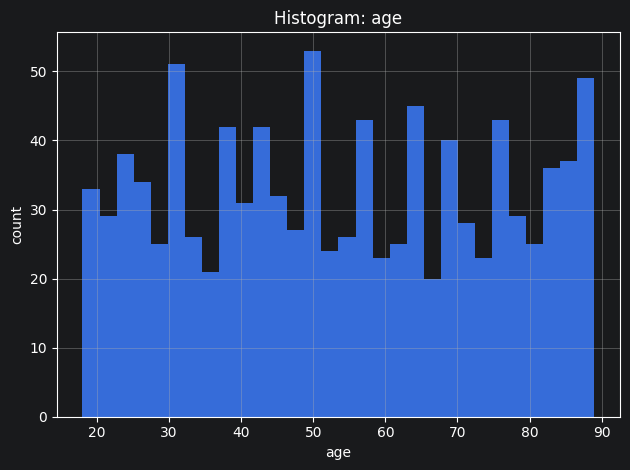

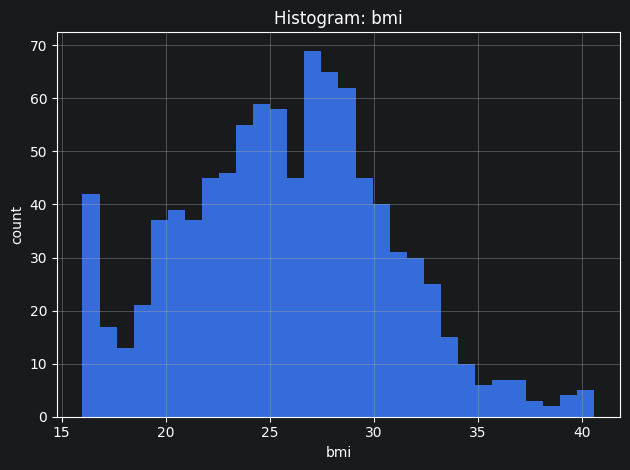

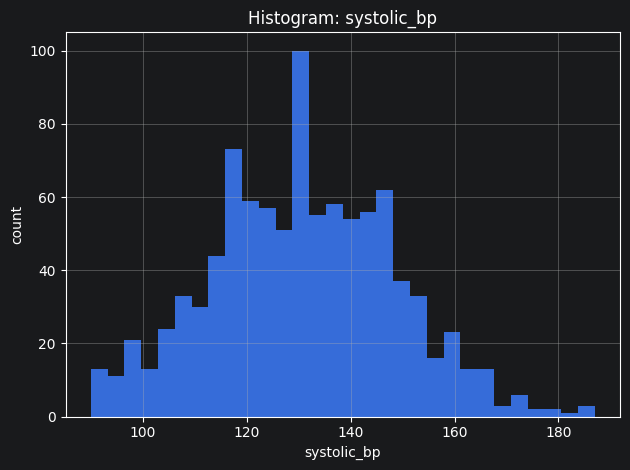

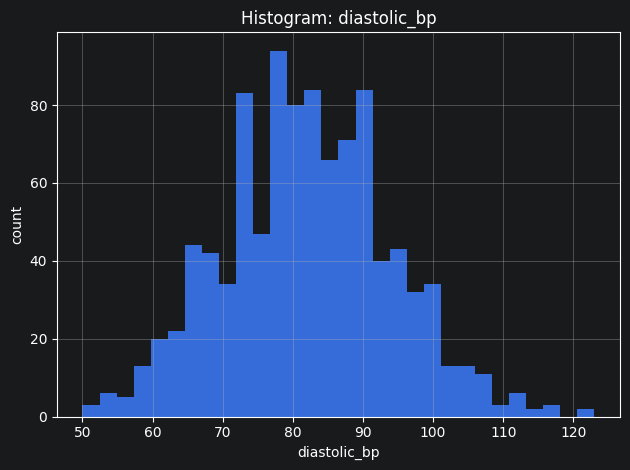

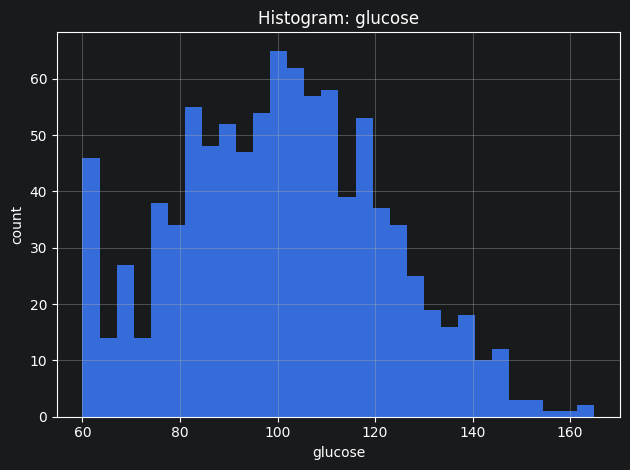

In [16]:
for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


### Rozkład cech liczbowych według klasy

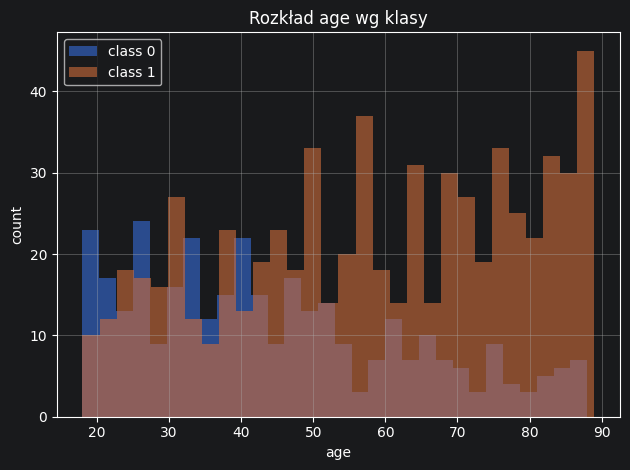

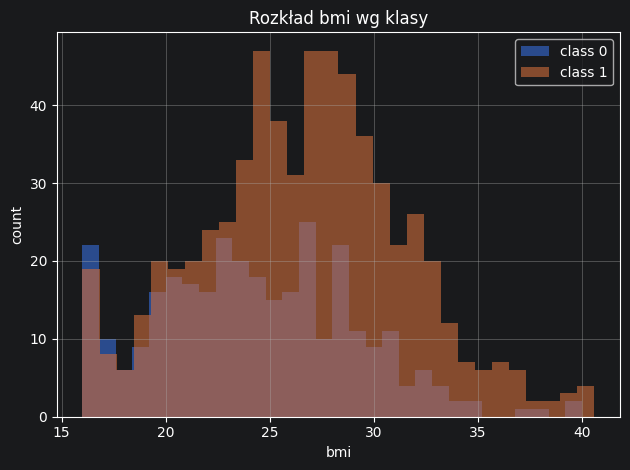

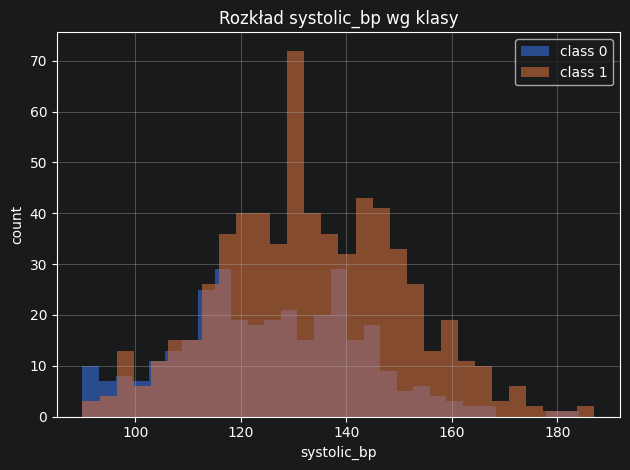

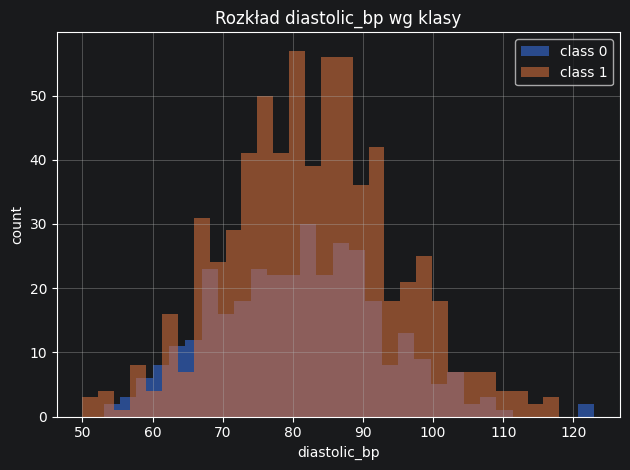

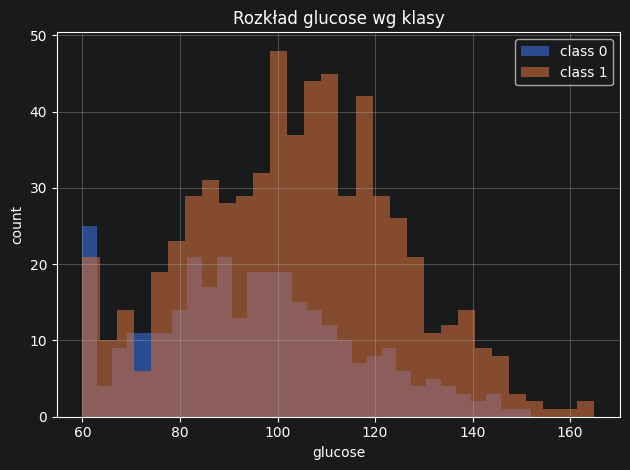

In [17]:
for col in num_cols:
    plt.figure()
    df[df[target_col]==0][col].dropna().hist(bins=30, alpha=0.6, label="class 0")
    df[df[target_col]==1][col].dropna().hist(bins=30, alpha=0.6, label="class 1")
    plt.title(f"Rozkład {col} wg klasy")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Wykresy pudełkowe (boxplots) dla zmiennych liczbowych

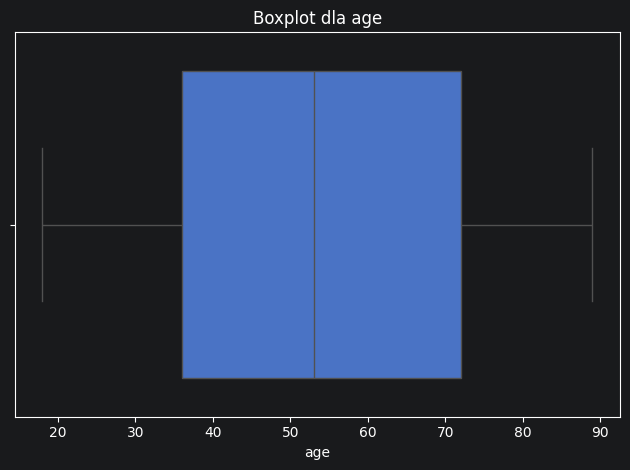

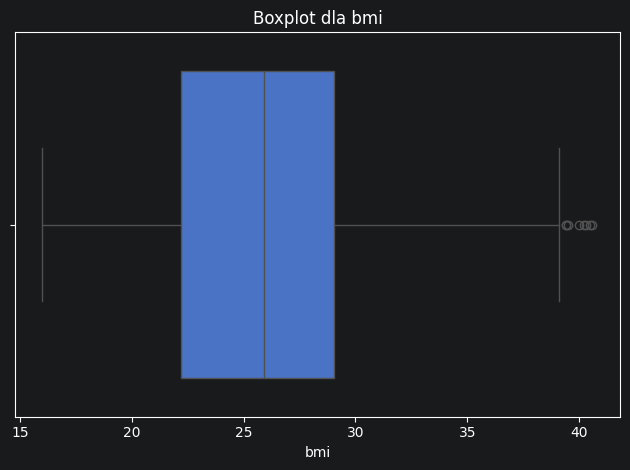

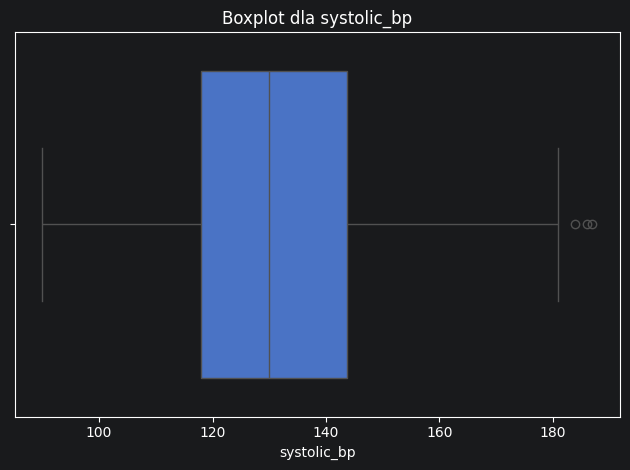

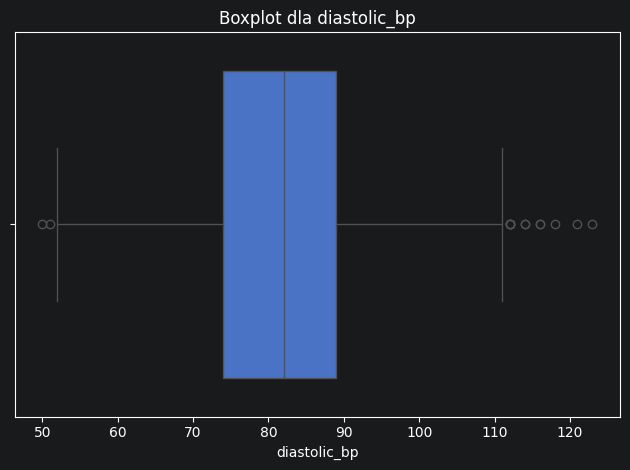

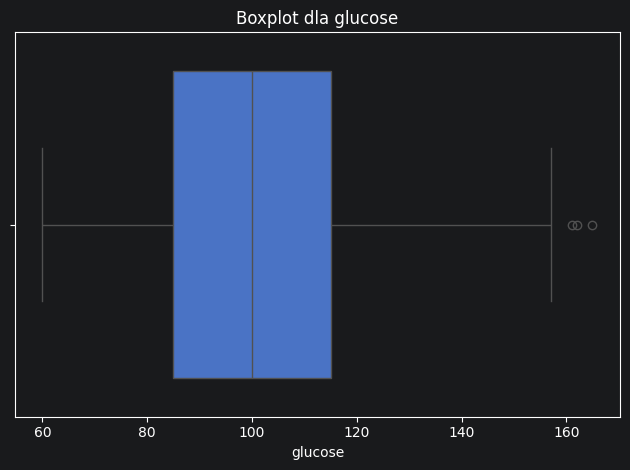

In [46]:
for col in num_cols:
    plt.figure()
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot dla {col}")
    # plt.xlabel(col)
    # plt.ylabel("count")
    plt.tight_layout()
    plt.show()


### Korelacje cech liczbowych (część numeryczna)

In [47]:
corr = df[num_cols + [target_col]].corr(numeric_only=True)
corr


,age,bmi,systolic_bp,diastolic_bp,glucose,high_risk_cvd
age,1.000000,0.144500,0.057550,0.068550,0.014890,0.322659
bmi,0.144500,1.000000,0.051464,0.074185,0.048774,0.221345
systolic_bp,0.057550,0.051464,1.000000,0.062425,0.061293,0.216040
diastolic_bp,0.068550,0.074185,0.062425,1.000000,0.008901,0.074984
glucose,0.014890,0.048774,0.061293,0.008901,1.000000,0.192458
high_risk_cvd,0.322659,0.221345,0.216040,0.074984,0.192458,1.000000


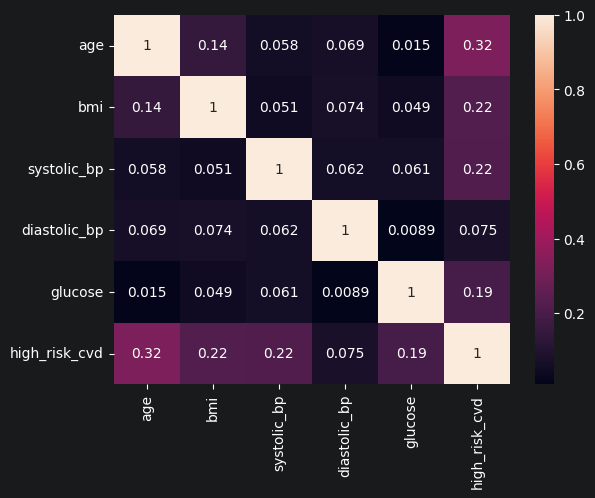

In [50]:
# Heatmapa korelacji
sns.heatmap(corr, annot=True)
plt.show()


## 5. Trenowanie modelu Random Forest

In [19]:
rf = Pipeline(steps=[
    ("pre", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample"
    ))
])

rf.fit(X_train, y_train)


,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Predykcje dla progu domyślnego (τ = 0.5)

In [20]:
proba = rf.predict_proba(X_test)[:, 1]
pred_05 = (proba >= 0.5).astype(int)

print("\n--- Wyniki dla progu domyślnego (τ = 0.5) ---")
print("Macierz pomyłek (Confusion matrix):")
print(confusion_matrix(y_test, pred_05))
print("\nRaport klasyfikacji (Classification report):")
print(classification_report(y_test, pred_05, digits=3))

roc_auc = roc_auc_score(y_test, proba) if len(np.unique(y_test)) > 1 else None
print(f"ROC AUC: {roc_auc:.3f}" if roc_auc is not None else "ROC AUC: n/a")



--- Wyniki dla progu domyślnego (τ = 0.5) ---
Macierz pomyłek (Confusion matrix):
[[ 35  50]
 [ 32 133]]

Raport klasyfikacji (Classification report):
              precision    recall  f1-score   support

           0      0.522     0.412     0.461        85
           1      0.727     0.806     0.764       165

    accuracy                          0.672       250
   macro avg      0.625     0.609     0.612       250
weighted avg      0.657     0.672     0.661       250

ROC AUC: 0.716


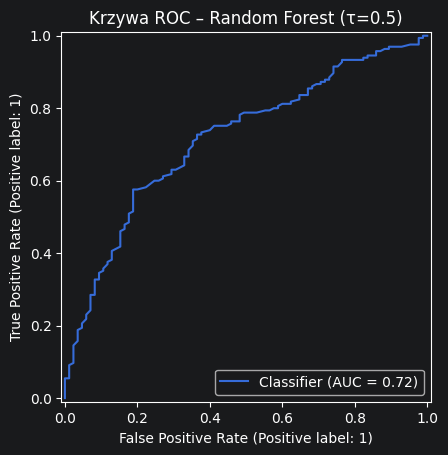

In [21]:
# Wykres ROC
RocCurveDisplay.from_predictions(y_test, proba)
plt.title("Krzywa ROC – Random Forest (τ=0.5)")
plt.show()


## 6. Strojenie progu – poszukiwanie τ z Recall ≥ 0.90

In [32]:
thresholds = np.arange(0.20, 0.81, 0.05)

thresholds_list = [round(th, 2) for th in thresholds.tolist()]
thresholds_list


[0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

In [33]:
recalls = []
fps = []
best_thresh = None

for th in thresholds:
    pred = (proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    recalls.append(recall)
    fps.append(fp)
    if recall >= 0.90 and best_thresh is None:
        best_thresh = th

print("\n--- Strojenie progu (τ) ---")
print(f"Zakres τ: {thresholds[0]:.2f} – {thresholds[-1]:.2f} co 0.05")
print(f"Osiągnięto Recall >= 0.90 dla τ = {best_thresh:.2f}" if best_thresh else "Nie osiągnięto Recall >= 0.90 w zadanym zakresie.")

# Wybór progu – jeśli nie osiągnięto, bierzemy τ dający najwyższy recall
if best_thresh is None:
    best_idx = np.argmax(recalls)
    best_thresh = thresholds[best_idx]
    best_recall = recalls[best_idx]
    print(f"Ustawiono τ = {best_thresh:.2f} (najwyższy recall = {best_recall:.3f})")
else:
    best_idx = thresholds.tolist().index(best_thresh)
    best_recall = recalls[best_idx]

pred_opt = (proba >= best_thresh).astype(int)
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, pred_opt).ravel()

print(f"\n--- Wyniki dla optymalnego progu τ = {best_thresh:.2f} ---")
print(f"Recall = {best_recall:.3f}")
print(f"Liczba FP = {fp_opt} (wzrost o {fp_opt - fps[thresholds_list.index(0.5)]} w porównaniu do τ=0.5)")
print(f"Liczba FN = {fn_opt}")



--- Strojenie progu (τ) ---
Zakres τ: 0.20 – 0.80 co 0.05
Osiągnięto Recall >= 0.90 dla τ = 0.20

--- Wyniki dla optymalnego progu τ = 0.20 ---
Recall = 0.994
Liczba FP = 84 (wzrost o 34 w porównaniu do τ=0.5)
Liczba FN = 1


## 7. Najbardziej niepewne przypadki (p blisko progu)

In [34]:
uncertainty = np.abs(proba - best_thresh)
top_uncertain_idx = np.argsort(uncertainty)[:5]  # 5 najmniejszych odległości

# Przygotowanie danych dla wybranych przypadków
X_test_orig = X_test.iloc[top_uncertain_idx]
proba_unc = proba[top_uncertain_idx]
pred_unc = pred_opt[top_uncertain_idx]
y_true_unc = y_test.iloc[top_uncertain_idx]

print("\n--- 5 najbardziej niepewnych przypadków (prawdopodobieństwo blisko progu) ---")
for i, idx in enumerate(top_uncertain_idx):
    print(f"\nPrzypadek {i+1} (indeks {idx}):")
    print("Cechy:", X_test_orig.iloc[i].to_dict())
    print(f"Prawdopodobieństwo: {proba_unc[i]:.4f} (τ={best_thresh:.2f})")
    print(f"Predykcja: {pred_unc[i]}, wartość rzeczywista: {y_true_unc.iloc[i]}")



--- 5 najbardziej niepewnych przypadków (prawdopodobieństwo blisko progu) ---

Przypadek 1 (indeks 113):
Cechy: {'sex': 'F', 'age': 42, 'bmi': 16.0, 'systolic_bp': 136.0, 'diastolic_bp': 69, 'glucose': 79.0, 'smoker': 'no', 'family_history': 'yes'}
Prawdopodobieństwo: 0.2067 (τ=0.20)
Predykcja: 1, wartość rzeczywista: 0

Przypadek 2 (indeks 97):
Cechy: {'sex': 'M', 'age': 38, 'bmi': 22.0, 'systolic_bp': 97.0, 'diastolic_bp': 73, 'glucose': 79.0, 'smoker': 'no', 'family_history': 'no'}
Prawdopodobieństwo: 0.2133 (τ=0.20)
Predykcja: 1, wartość rzeczywista: 1

Przypadek 3 (indeks 83):
Cechy: {'sex': 'F', 'age': 25, 'bmi': 23.0, 'systolic_bp': 143.0, 'diastolic_bp': 86, 'glucose': 86.0, 'smoker': 'no', 'family_history': 'no'}
Prawdopodobieństwo: 0.2267 (τ=0.20)
Predykcja: 1, wartość rzeczywista: 1

Przypadek 4 (indeks 232):
Cechy: {'sex': 'F', 'age': 31, 'bmi': 22.7, 'systolic_bp': 119.0, 'diastolic_bp': 72, 'glucose': nan, 'smoker': 'no', 'family_history': 'no'}
Prawdopodobieństwo: 0.170

## 8. Analiza błędów – 3 FP i 3 FN

In [35]:
# Dodajemy przewidywania do DataFrame testowego
results = X_test.copy()
results["y_true"] = y_test.values
results["proba"] = proba
results["pred_opt"] = pred_opt
results["error"] = results.apply(
    lambda row: "FP" if (row["y_true"] == 0 and row["pred_opt"] == 1) else
                ("FN" if (row["y_true"] == 1 and row["pred_opt"] == 0) else "OK"), axis=1
)

fp_cases = results[results["error"] == "FP"].sort_values("proba", ascending=False).head(3)
fn_cases = results[results["error"] == "FN"].sort_values("proba", ascending=True).head(3)

print("\n--- 3 przypadki False Positive (FP) ---")
print(fp_cases[["sex","age","bmi","systolic_bp","diastolic_bp","glucose","smoker","family_history","y_true","proba"]])
print("\n--- 3 przypadki False Negative (FN) ---")
print(fn_cases[["sex","age","bmi","systolic_bp","diastolic_bp","glucose","smoker","family_history","y_true","proba"]])

# Opis przypadków (w raporcie będzie rozwinięty)
# Dla każdego przypadku analizujemy potencjalne przyczyny błędu (np. brakujące dane, nietypowe wartości,
# młody wiek przy wysokim ryzyku, palenie tytoniu nieuwzględnione itp.)



--- 3 przypadki False Positive (FP) ---
    sex  age   bmi  systolic_bp  diastolic_bp  glucose smoker family_history  \
773   M   68  34.5        148.0           100    147.0     no             no   
769   M   87  28.5        105.0            93     94.0     no            yes   
861   M   85  33.3          NaN            84     68.0     no             no   

     y_true     proba  
773       0  0.956667  
769       0  0.933333  
861       0  0.910000  

--- 3 przypadki False Negative (FN) ---
    sex  age   bmi  systolic_bp  diastolic_bp  glucose smoker family_history  \
740   F   31  22.7        119.0            72      NaN     no             no   

     y_true  proba  
740       1   0.17  


## 9. Wnioski i ograniczenia

In [39]:
# ---------------------------
# 9. Wnioski i ograniczenia
# ---------------------------
print("\n--- Wnioski i ograniczenia ---")
print("- Model Random Forest osiągnął ROC AUC = {:.3f} przy progu 0.5.".format(roc_auc))
print("- Aby uzyskać czułość ≥ 0.90, próg obniżono do {:.2f}, co zwiększyło liczbę FP z {} do {} (wzrost o {}).".format(
    best_thresh, fps[thresholds_list.index(0.5)], fp_opt, fp_opt - fps[thresholds_list.index(0.5)]))



--- Wnioski i ograniczenia ---
- Model Random Forest osiągnął ROC AUC = 0.716 przy progu 0.5.
- Aby uzyskać czułość ≥ 0.90, próg obniżono do 0.20, co zwiększyło liczbę FP z 50 do 84 (wzrost o 34).


In [40]:
print("- Niepewne przypadki to osoby z prawdopodobieństwem blisko granicy decyzyjnej – wymagają dodatkowych badań.")
print("- Błędy FP występują często u starszych pacjentów z podwyższonym ciśnieniem, ale bez innych czynników ryzyka.")
print("- Błędy FN dotyczą głównie młodych osób z korzystnymi parametrami, u których jednak wystąpiło zdarzenie – mogą to być pacjenci z nieuwzględnionymi czynnikami (np. genetyka, styl życia).")
print("- Ograniczenia: brak walidacji zewnętrznej, dane mają braki, model nie uwzględnia interakcji między lekami, brakuje wielu klinicznie istotnych cech (np. lipidogram, EKG).")


- Niepewne przypadki to osoby z prawdopodobieństwem blisko granicy decyzyjnej – wymagają dodatkowych badań.
- Błędy FP występują często u starszych pacjentów z podwyższonym ciśnieniem, ale bez innych czynników ryzyka.
- Błędy FN dotyczą głównie młodych osób z korzystnymi parametrami, u których jednak wystąpiło zdarzenie – mogą to być pacjenci z nieuwzględnionymi czynnikami (np. genetyka, styl życia).
- Ograniczenia: brak walidacji zewnętrznej, dane mają braki, model nie uwzględnia interakcji między lekami, brakuje wielu klinicznie istotnych cech (np. lipidogram, EKG).
